In [18]:
#exercise 1

In [19]:
file_path = input("Enter the path to the CSV file: ")
records = []
with open(file_path, 'r') as file:
    csv_reader = csv.DictReader(file)
    for row in csv_reader:
    records.append(row)
total = sum(float(record['Grade']) for record in records)
average = total / len(records)
print(f"Average Grade: {average}")
print("--------------------")
filtered_records = [record for record in records if float(record['Grade']) >= 80.0]
print("Student Report")
print("--------------")
for record in filtered_records:
print(f"Name: {record['Name']}")
print(f"Grade: {record['Grade']}")
print("------------------")

IndentationError: expected an indented block after 'for' statement on line 5 (3476067297.py, line 6)

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import random

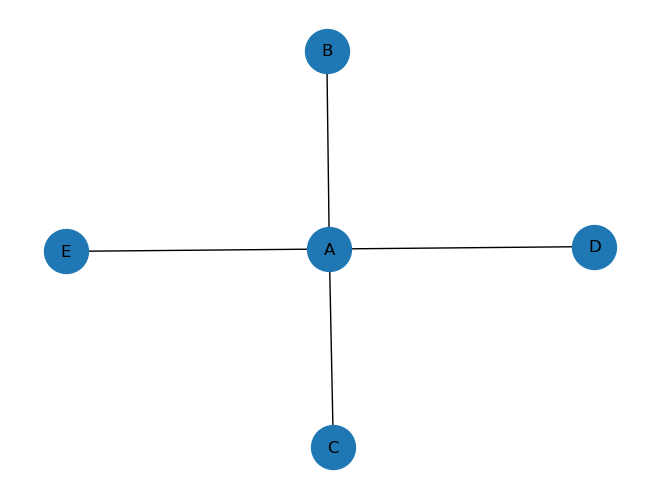

In [21]:
#Make an empty network
graph = nx.Graph()
#Add pages
graph.add_nodes_from(["A", "B", "C", "D", "E"])
#Add edges
edges = [("A", "B"),
    ("A", "C"),
    ("A", "D"),
    ("A", "E")]
graph.add_edges_from(edges)
#Draw the graph
nx.draw(graph, with_labels=True, node_size = 1000)
plt.show()

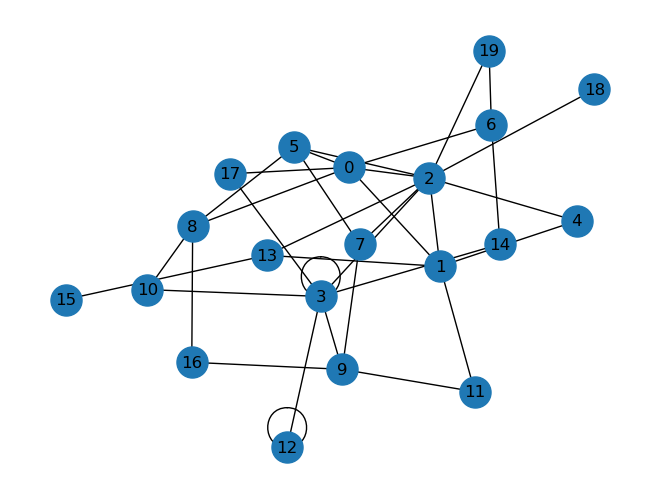

In [22]:
def create_network(
      number_of_nodes: int,
      edges_per_node: int
) -> nx.Graph:
    """Create a growing undirected network manually.
    New nodes preferentially attach to existing nodes with higher degrees.
    Arguments:
    number_of_nodes: The total number of nodes in the network.
    edges_per_node: The number of edges to attach from a new node to existing nodes.
    Returns:
    A networkx undirected graph.
    Worked on by Jeanuar"""

    graph = nx.Graph()
    graph.add_edges_from([(0,1), (1,2), (2,0)])

    #Add new nodes one by one
    for new_node in range(3, number_of_nodes):
        graph.add_node(new_node)

        for _ in range(edges_per_node):
            #higher degree nodes have a higher probability of being chosen
            nodes = list(graph.nodes())
            weights = [graph.degree(node) for node in nodes]

            #Choose a node weighted by degree
            target = random.choices(nodes, weights=weights, k=1)[0]

            if not graph.has_edge(new_node, target):
                graph.add_edge(new_node, target)

    return graph
#Create a network with 20 nodes
graph = create_network(20, 2)
#display the network
nx.draw(graph, with_labels=True, node_size=500)
plt.show()

In [23]:
def simulate_pagerank(
        graph: nx.Graph,
        steps: int = 10000

) -> dict[int, float]:
    """Estimate PageRank by simulating a random surfer.
    The surfer starts at a random node and keeps moving 
    to a randomly selected neighbor.
    Arguments:
    graph: The network to explore
    steps: Number of moves to simulate
    Return:
    A dictionary mapping each node to its estimated PageRank probability.
    Worked on by Jeanuar"""

    nodes = list(graph.nodes())

    #Start at a random node
    current_node = random.choice(nodes)
    #Count how many times we visit each node
    visits = {node: 0 for node in nodes}

    for _ in range(steps):
        visits[current_node] += 1
        #Move to a randomly selected neighbor
        neighbors = list(graph.neighbors(current_node))
        current_node = random.choice(neighbors)

    #Convert visit counts into probabilities
    total_visits = sum(visits.values())

    pagerank = { node: count / total_visits 
                for node, count in visits.items() }
    return pagerank

#Estimate PageRank for your network
pagerank = simulate_pagerank(graph)
#Print the results
for node, score in pagerank.items():
    print(f"Node {node}: {score:.4f}")

Node 0: 0.0913
Node 1: 0.0779
Node 2: 0.1367
Node 3: 0.1034
Node 4: 0.0327
Node 5: 0.0642
Node 6: 0.0456
Node 7: 0.0453
Node 8: 0.0615
Node 9: 0.0583
Node 10: 0.0310
Node 11: 0.0296
Node 12: 0.0299
Node 13: 0.0453
Node 14: 0.0283
Node 15: 0.0150
Node 16: 0.0273
Node 17: 0.0302
Node 18: 0.0155
Node 19: 0.0310


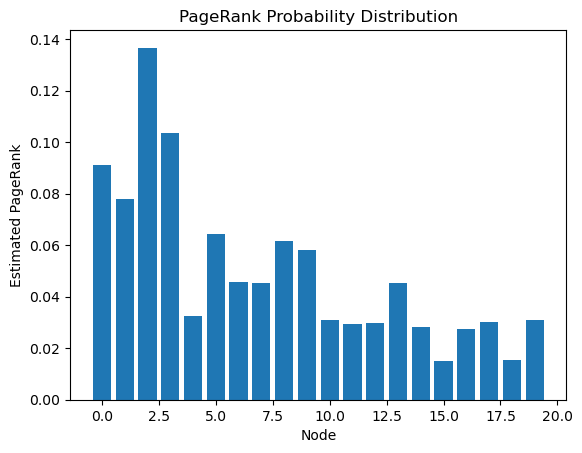

Total probability: 1.0


In [26]:
def plot_pagerank(pagerank: dict[int, float]) -> None:
    """Plot the PageRank scores as a bar chart.
    Arguments:
    pagerank: Dictionary mapping nodes to PageRank scores.
    Returns: None
    Worked on by Jeanuar"""
    nodes = list(pagerank.keys())
    scores = list(pagerank.values())
    plt.bar(nodes, scores)
    plt.xlabel("Node")
    plt.ylabel("Estimated PageRank")
    plt.title("PageRank Probability Distribution")
    plt.show()

#Plot the results
plot_pagerank(pagerank)
total = sum(pagerank.values())
print(f"Total probability: {total}")
